--- Dataset Structure ---
Class: COVID | Images: 3616
Class: Lung_Opacity | Images: 6012
Class: Normal | Images: 10192
Class: Viral Pneumonia | Images: 1345


C:\Users\harsh\AppData\Local\Temp\ipykernel_13500\2721974684.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette="viridis")


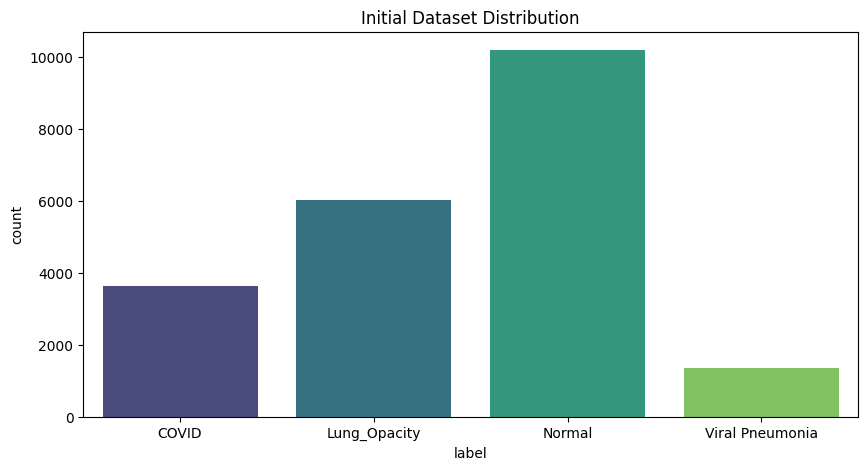


--- Pre-processed Split Distribution ---
Train set: 14815 images
Validation set: 2117 images
Test set: 4233 images


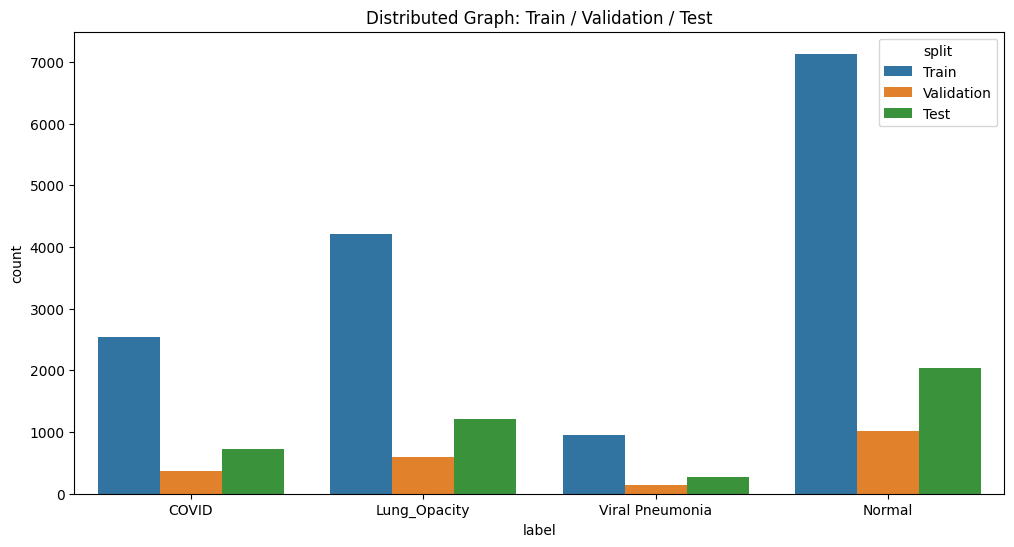

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import transforms, models
from sklearn.model_selection import train_test_split

# 1. Dataset Path and Structure
root_dir = 'COVID-19_Radiography_Dataset'
classes = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

print("--- Dataset Structure ---")
data_list = []

for cls in classes:
    # We target the 'images' folder and ignore 'masks'
    img_path = os.path.join(root_dir, cls, 'images')
    images = [os.path.join(img_path, f) for f in os.listdir(img_path) if f.endswith('.png')]
    print(f"Class: {cls} | Images: {len(images)}")
    
    for img in images:
        data_list.append([img, cls])

# Create a DataFrame for easier handling
df = pd.DataFrame(data_list, columns=['image_path', 'label'])
# Map labels to integers
label_map = {cls: i for i, cls in enumerate(classes)}
df['label_idx'] = df['label'].map(label_map)

# 2. Initial Distributed Graph
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', palette="viridis")
plt.title("Initial Dataset Distribution")
plt.show()

# 3. Custom Dataset Class
class CovidDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx, 0]
        # ResNet expects 3 channels (RGB). .convert('RGB') handles grayscale to 3-channel.
        image = Image.open(img_name).convert('RGB')
        label = int(self.dataframe.iloc[idx, 2])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 4. Data Preprocessing
# Even for grayscale, we normalize using ImageNet stats because we use pretrained ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Stratified Split (70:10:20)
# Split 1: 70% Train, 30% Temp
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label_idx'], random_state=42
)

# Split 2: Divide Temp (30%) into Val (10% total) and Test (20% total)
# 10 is 1/3rd of 30, so test_size=0.666 to get 20%
val_df, test_df = train_test_split(
    temp_df, test_size=0.6666, stratify=temp_df['label_idx'], random_state=42
)

# Create Dataset Objects
train_dataset = CovidDataset(train_df, transform=transform)
val_dataset = CovidDataset(val_df, transform=transform)
test_dataset = CovidDataset(test_df, transform=transform)

# 6. Show Data Structure and Print Split Distribution
print(f"\n--- Pre-processed Split Distribution ---")
print(f"Train set: {len(train_dataset)} images")
print(f"Validation set: {len(val_dataset)} images")
print(f"Test set: {len(test_dataset)} images")

# Prepare data for plotting
train_df['split'] = 'Train'
val_df['split'] = 'Validation'
test_df['split'] = 'Test'
combined_df = pd.concat([train_df, val_df, test_df])

plt.figure(figsize=(12, 6))
sns.countplot(data=combined_df, x='label', hue='split')
plt.title("Distributed Graph: Train / Validation / Test")
plt.show()

# 7. Model Initialization (Ready for Training)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = models.resnet18(weights='IMAGENET1K_V1')
# num_ftrs = model.fc.in_features
# model.fc = torch.nn.Linear(num_ftrs, 4) # 4 output classes
# model = model.to(device)

# print(f"Model successfully loaded onto: {device}")

# DataLoaders for training
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Training started on cuda...
Epoch 1/60 | Train Loss: 0.6852 Acc: 0.7299 | Val Loss: 0.6632 Acc: 0.7548
Epoch 2/60 | Train Loss: 0.4372 Acc: 0.8369 | Val Loss: 0.5166 Acc: 0.8181
Epoch 3/60 | Train Loss: 0.3410 Acc: 0.8746 | Val Loss: 0.3418 Acc: 0.8729
Epoch 4/60 | Train Loss: 0.2945 Acc: 0.8904 | Val Loss: 0.3057 Acc: 0.8923
Epoch 5/60 | Train Loss: 0.2560 Acc: 0.9049 | Val Loss: 0.3335 Acc: 0.8923
Epoch 6/60 | Train Loss: 0.2246 Acc: 0.9167 | Val Loss: 0.3368 Acc: 0.8777
Epoch 7/60 | Train Loss: 0.1933 Acc: 0.9283 | Val Loss: 0.3467 Acc: 0.8720
Epoch 8/60 | Train Loss: 0.1790 Acc: 0.9347 | Val Loss: 0.2863 Acc: 0.8880
Epoch 9/60 | Train Loss: 0.1504 Acc: 0.9459 | Val Loss: 0.2614 Acc: 0.9074
Epoch 10/60 | Train Loss: 0.1388 Acc: 0.9487 | Val Loss: 0.3534 Acc: 0.8795
Epoch 11/60 | Train Loss: 0.1103 Acc: 0.9613 | Val Loss: 0.3508 Acc: 0.8899
Epoch 12/60 | Train Loss: 0.1066 Acc: 0.9604 | Val Loss: 0.3305 Acc: 0.8923
Epoch 13/60 | Train Loss: 0.0822 Acc: 0.9697 | Val Loss: 0.3298 Acc: 

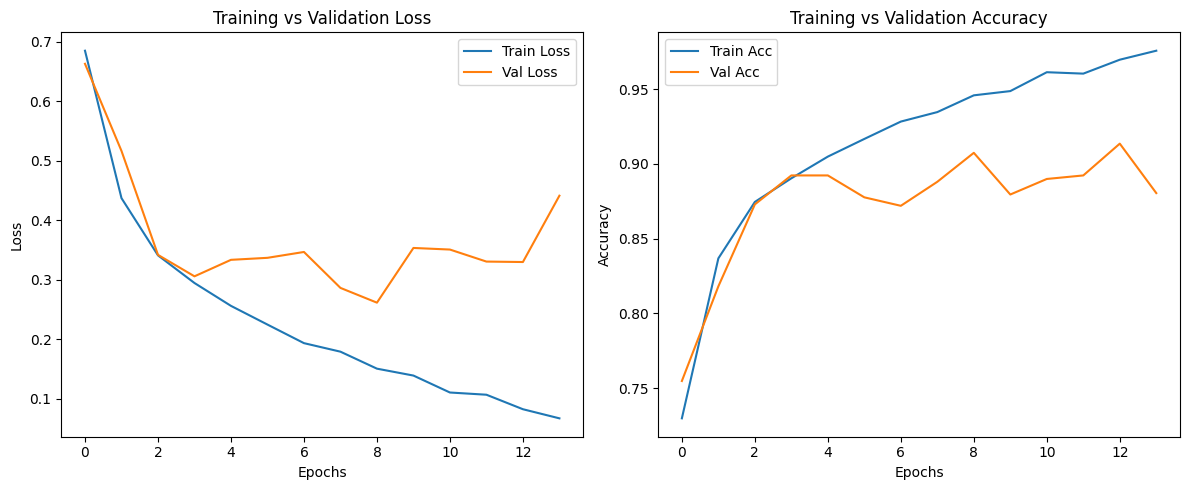


--- FINAL TEST METRICS ---
Accuracy:  0.9171
Precision: 0.9175
Recall:    0.9171
F1 Score:  0.9165


In [2]:
import torch
import torch.nn as nn
from torchvision.models import resnet18
model = resnet18(weights=None)

import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

num_classes = 4


# --- 2. Training Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 4
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)   
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# To store metrics for curves
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

def get_metrics(loader, model):
    model.eval()
    all_labels, all_preds = [], []
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    avg_loss = val_loss / len(loader.dataset)
    return acc, avg_loss, all_labels, all_preds

# --- 3. Training Loop ---
patience = 5
best_val_loss = float('inf')
counter = 0
epochs = 60

print(f"Training started on {device}...")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
        
    # Calculate Epoch Metrics
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = train_correct.double() / len(train_loader.dataset)
    
    epoch_val_acc, epoch_val_loss, _, _ = get_metrics(val_loader, model)
    
    # Save History
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc.item())
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
    
    # Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# --- 4. Plot Training vs Validation Curves ---
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# --- 5. Final Detailed Metrics ---
model.load_state_dict(torch.load('best_model.pth'))
test_acc, _, y_true, y_pred = get_metrics(test_loader, model)

print("\n--- FINAL TEST METRICS ---")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_true, y_pred, average='weighted'):.4f}")

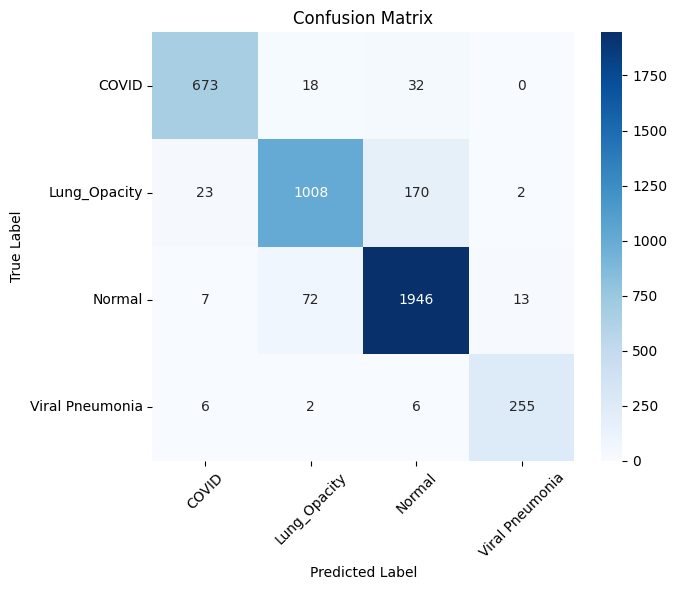

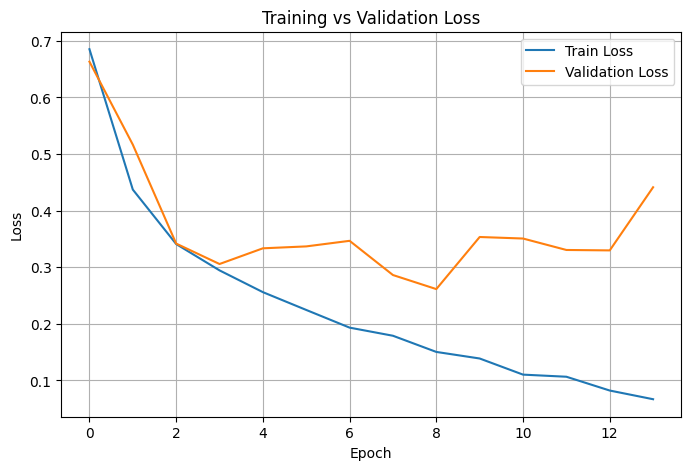

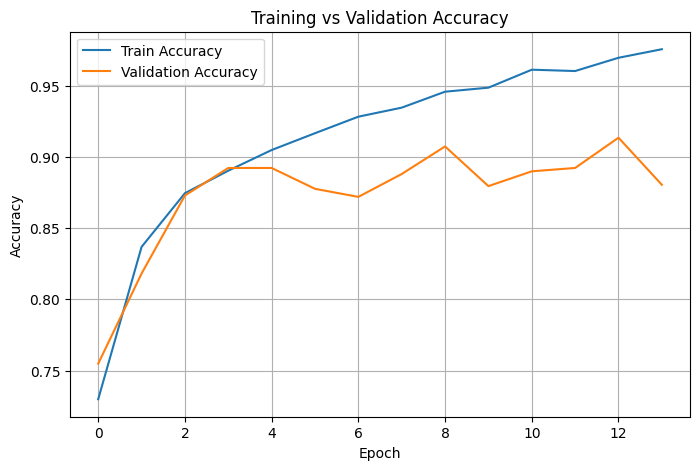

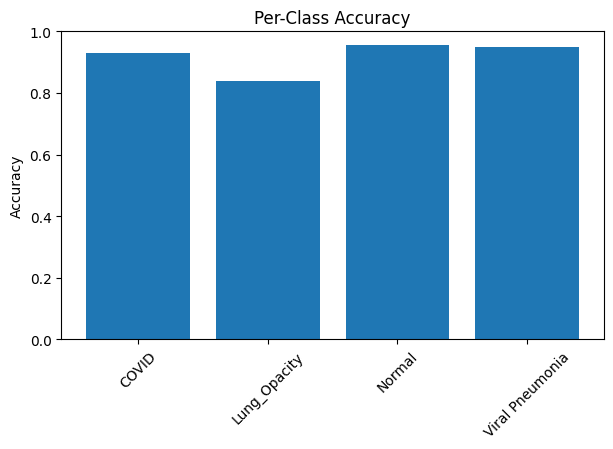

COVID Accuracy: 0.9308
Lung_Opacity Accuracy: 0.8379
Normal Accuracy: 0.9549
Viral Pneumonia Accuracy: 0.9480


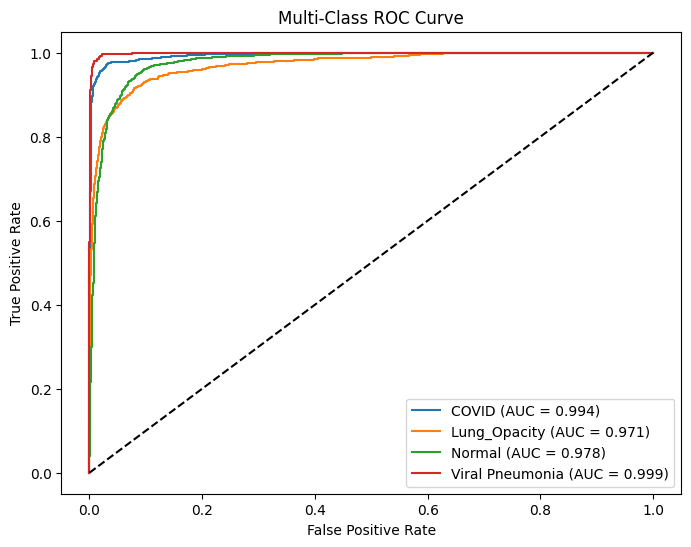

In [3]:
###Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt



cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()







###Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


###Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()



#####Per-class Accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(7,4))
plt.bar(classes, per_class_acc)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.show()

for i, acc in enumerate(per_class_acc):
    print(f"{classes[i]} Accuracy: {acc:.4f}")


##ROC Curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize labels
y_true_bin = label_binarize(y_true, classes=[0,1,2,3])

# Get predicted probabilities
model.eval()
all_probs = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)

plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

